# 06g · GSE65391 · RNA_array · pvclust-py on the children's profiles (Python)

Reads `pg_profile_797.csv` and `pg_profile_modules16.csv` (notebook 06d) and `pg_paper_groups.csv`
(notebook 06e). Writes the dendrograms to `figures/GSE65391/`.

**Method** as in notebooks 08c and 08d: pvclust-py (NIH-NLM/pvclust-py, pinned commit 6b0c3bf; Suzuki R,
Shimodaira H. *Bioinformatics* 2006;22:1540-1542), Minkowski p = 2, `ward.D2`, 1,000 bootstrap replicates
per scale, seed 20260928. The children are clustered; the features are resampled.

| profile | features resampled | note |
|---|---|---|
| 797 probes (paper's transcripts) | 797 | probes with an r in every child |
| 14 array modules (ours) | 14 | fewer than 30 units: pvclust-py warns that AU is poorly determined |

The five-network profile has only 5 features and cannot be bootstrapped meaningfully; it is not used here.

**Test.** Which clusters of children reach AU >= 0.95 (pvpick)? Are any of them near the size of the paper's
groups (4 to 17 children)?

## Load the profiles written by notebook 06d

In [1]:
import warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import dendrogram as tree
from pvclust_py.core import pvclust, pvpick

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "endotypes-transcriptomics.yml").exists())
ART  = ROOT / "data" / "run_artifacts" / "GSE65391"
FIG  = ROOT / "figures" / "GSE65391"; FIG.mkdir(parents=True, exist_ok=True)
SEED = 20260928
pd.set_option("display.max_colwidth", None)   # show every cluster member

r797 = pd.read_csv(ART / "pg_profile_797.csv", index_col=0).dropna(axis=1)
m16  = pd.read_csv(ART / "pg_profile_modules16.csv", index_col=0)
g7   = pd.read_csv(ART / "pg_paper_groups.csv").set_index("subject")["group"]
{"r797": r797.shape, "modules16": m16.shape}

{'r797': (83, 797), 'modules16': (83, 14)}

**Explanation**
- `pandas` holds tables in Python (McKinney W. Data structures for statistical computing in Python.
  *Proceedings of the 9th Python in Science Conference* 2010:56-61).
- `matplotlib` draws the figure (Hunter JD. Matplotlib: a 2D graphics environment. *Comput Sci Eng*
  2007;9:90-95); `scipy.cluster.hierarchy.dendrogram` draws the tree from the linkage matrix (Virtanen P et
  al. SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nat Methods* 2020;17:261-272).
- The imports and `ROOT`, `ART`, `FIG` as in notebook 08c.
- `pd.read_csv(..., index_col=0)` reads each profile with the child identifiers as row names.
- `.dropna(axis=1)` removes the probes with a missing correlation in any child; `axis=1` means columns.
- `g7` maps each child to its 06e group. For example, `g7["SLE-121"]` is that child's group number.

## Run pvclust on the children

In [2]:
results = {}
for name, P in {"797 probes": r797, "14 modules": m16}.items():
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        results[name] = pvclust(P, cluster="rows", method_dist="minkowski", method_hclust="ward.D2", nboot=1000, seed=SEED)
    for w in caught:
        print(name, "- pvclust-py warning:", w.message)

797 probes - pvclust-py warning: clustering rows means resampling the 797 columns, which are typically correlated rather than independent draws; AU will be anti-conservative (optimistic). Fine for the companion dendrogram of a two-way figure -- just do not quote these p-values as if they were the column ones.


14 modules - pvclust-py warning: clustering rows means resampling the 14 columns, which are typically correlated rather than independent draws; AU will be anti-conservative (optimistic). Fine for the companion dendrogram of a two-way figure -- just do not quote these p-values as if they were the column ones.
14 modules - pvclust-py warning: only 14 resampling units: the multiscale bootstrap has little to work with, and AU will be poorly determined. If these are genes being resampled to assess patient clusters, AU is also anti-conservative.


**Explanation**
- `results = {}` starts an empty dictionary: a set of named results.
- For each profile, `pvclust(P, cluster="rows", ...)` clusters the rows, the children, and resamples the
  columns, the probes or modules. Settings as in notebook 08c.
- `warnings.catch_warnings(record=True)` collects the warnings pvclust-py gives, and the loop prints them.

## Pick the supported clusters

In [3]:
tables = {}
for name, res in results.items():
    picked = pvpick(res, alpha=0.95)
    tables[name] = pd.DataFrame([{"size": len(e["members"]), "AU": round(e["au"], 3), "BP": round(e["bp"], 3),
                                  "06e groups of members": ", ".join(str(g7[m]) for m in e["members"]),
                                  "members": ", ".join(e["members"])} for e in picked]
                                ).sort_values(["size", "AU"], ascending=False).reset_index(drop=True)
    print(f"{name}: {len(picked)} clusters of children with AU >= 0.95")
tables["797 probes"]

797 probes: 2 clusters of children with AU >= 0.95
14 modules: 7 clusters of children with AU >= 0.95


,size,AU,BP,06e groups of members,members
0,4,0.96,0.762,"1, 1, 1, 1","SLE-143, SLE-245, SLE-281, SLE-339"
1,2,1.00,1.000,"2, 2","SLE-121, SLE-79"


**Explanation**
- `pvpick(res, alpha=0.95)` returns the largest non-overlapping clusters with AU of at least 0.95 (see
  notebook 08c).
- For each cluster, one row: its size, AU, BP, the 06e group of each member, and the members.
- The table of the 797-probe profile is shown here; the next cell shows the 16-module one.

**Result, 797 probes.** 2 clusters of children reach AU >= 0.95: one of 4 children (AU = 0.960, BP = 0.762),
all in 06e group 1, and one of 2 (AU = 1.000, BP = 1.000). None is near the size of the paper's groups
(4 to 17), apart from the one of 4, which matches only PG7's size.

In [4]:
tables["14 modules"]

,size,AU,BP,06e groups of members,members
0,7,0.985,0.004,"1, 1, 1, 1, 1, 1, 1","SLE-144, SLE-155, SLE-169, SLE-175, SLE-202, SLE-40, SLE-78"
1,6,0.980,0.010,"2, 2, 2, 2, 2, 1","SLE-141, SLE-213, SLE-218, SLE-231, SLE-233, SLE-308"
2,6,0.954,0.012,"1, 1, 1, 1, 1, 1","SLE-110, SLE-133, SLE-170, SLE-179, SLE-34, SLE-90"
3,5,0.970,0.003,"2, 2, 1, 7, 2","SLE-121, SLE-183, SLE-55, SLE-60, SLE-79"
4,4,0.972,0.194,"1, 1, 1, 1","SLE-199, SLE-201, SLE-234, SLE-254"
5,3,0.989,0.487,"2, 2, 2","SLE-166, SLE-21, SLE-252"
6,2,0.982,0.758,"2, 2","SLE-123, SLE-150"


**Explanation**
- Shows the table for the 16-module profile.

**Result, 14 modules.** 7 clusters reach AU >= 0.95, of 2 to 7 children, most with low BP (0.003 to 0.758).
pvclust-py warns that with 14 resampling units AU is poorly determined, and that on this axis it is
anti-conservative.

## Draw the trees with AU and BP

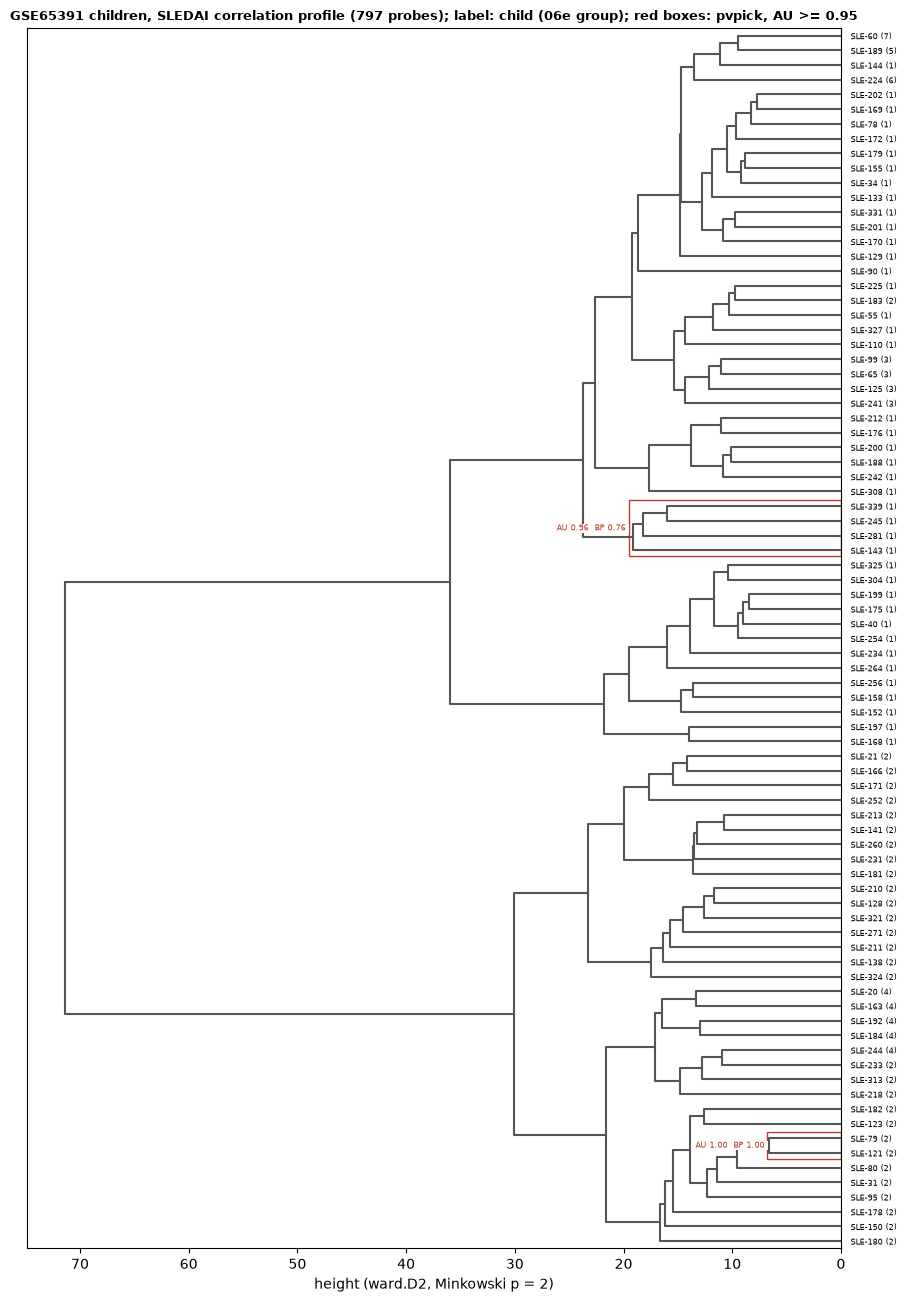

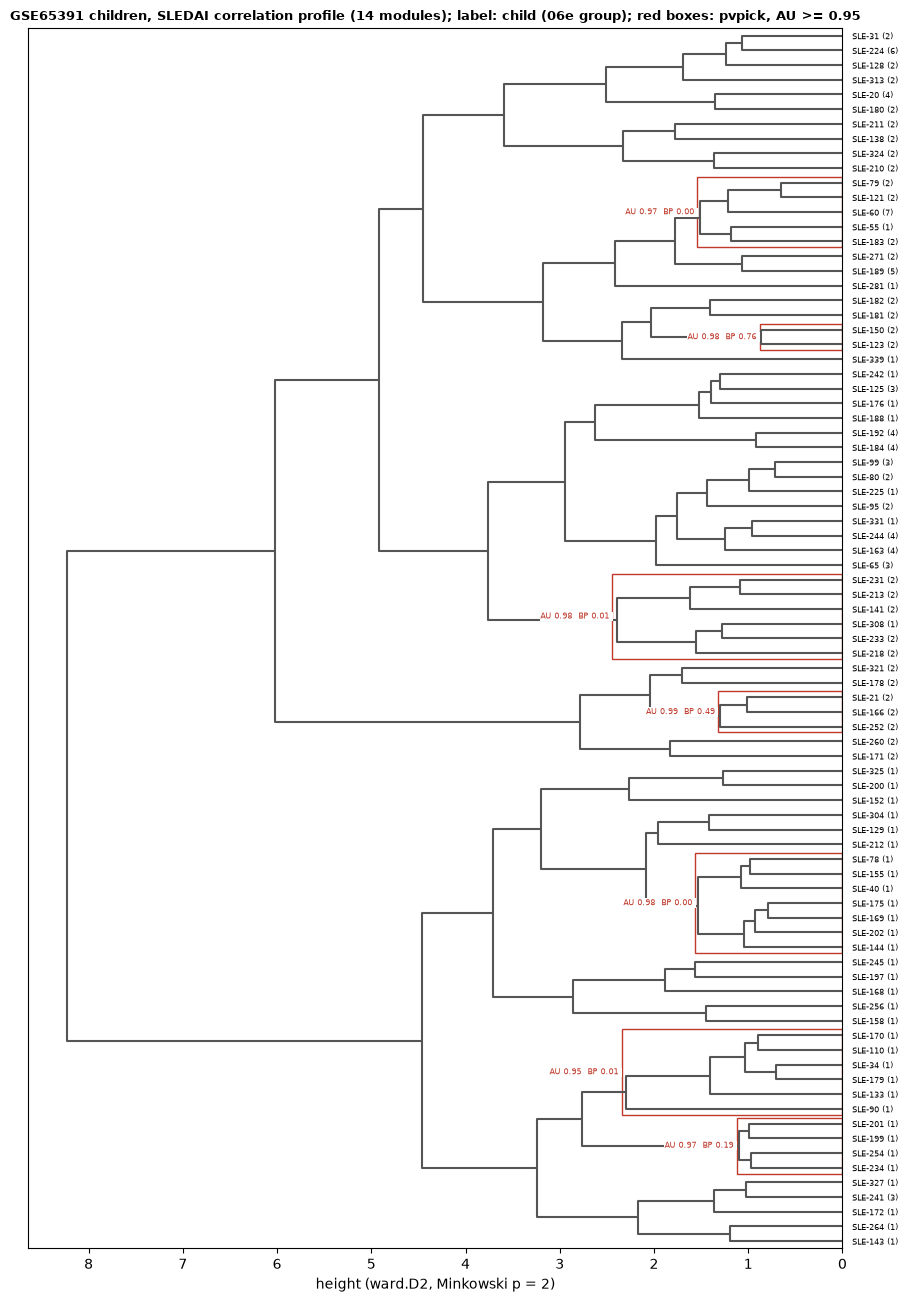

In [5]:
# The pvclust tree with every child labelled. Each red box is one pvpick cluster (AU >= 0.95),
# labelled with its AU and BP values (AU: approximately unbiased; BP: ordinary bootstrap).
def pv_figure(res, picked, title, path):
    n = len(res.labels)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.14 * n + 1.5)))
    d = tree(res.linkage, labels=[f"{l} ({g7[l]})" for l in res.labels], orientation="left", ax=ax,
             color_threshold=0, above_threshold_color="#555555", leaf_font_size=6)
    pos = {res.labels[j]: 5 + 10 * k for k, j in enumerate(d["leaves"])}
    for e in picked:
        ys = [pos[m] for m in e["members"]]
        h = res.linkage[e["merge_order"] - 1, 2] * 1.02
        ax.add_patch(Rectangle((0, min(ys) - 4), h, max(ys) - min(ys) + 8, fill=False, edgecolor="#C0392B", lw=1))
        ax.text(h, (min(ys) + max(ys)) / 2, f"AU {e['au']:.2f}  BP {e['bp']:.2f} ", color="#C0392B",
                fontsize=6, ha="right", va="center",
                bbox=dict(facecolor="white", edgecolor="none", pad=0.3))
    ax.set_xlabel("height (ward.D2, Minkowski p = 2)")
    ax.set_title(title, fontsize=9, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path, dpi=300)
    plt.show()

for name, res in results.items():
    pv_figure(res, pvpick(res, alpha=0.95),
              f"GSE65391 children, SLEDAI correlation profile ({name}); label: child (06e group); red boxes: pvpick, AU >= 0.95",
              FIG / f"06g_PG_pvclust_{name.replace(' ', '_')}.png")

**Explanation**
- `pv_figure()` as in notebook 08c. Each child is labelled with its 06e group, for example `SLE-121 (2)`.
- One figure per profile, saved as a 300 dpi PNG.

## Summary: claim B6 (seven patient groups)

- **The children.** The paper's 80 are, by their totals, our 83 less three Hispanic children (notebook 06d).
- **The paper's method** (1 - Pearson r on the 797-transcript profile, cut at seven, with average linkage,
  which is our choice because the paper names none) gives groups of 41, 30, 5, 4, 1, 1 and 1, not the
  paper's 17, 16, 13, 11, 10, 9 and 4 (notebook 06e).
- **Our methods:** k-means gives its highest mean silhouette at K = 2 for both profiles (0.313 and 0.155;
  K = 7 gives 0.275 and 0.124; notebook 06f), and pvclust supports clusters of 2 to 7 children (this notebook).
- **Not reproduced.** The children's SLEDAI correlations combine the paper's five signatures in different
  ways, but the paper's seven groups of 4 to 17 children are not recovered.